In [1]:
import torch
from torch.utils.data import DataLoader, ConcatDataset

from shapenet_dataset import ShapeNetDataset, shapenet_id_to_category
from visualize import plot_pointclouds, visualize_reconstructions

# autoreload py
%load_ext autoreload
%autoreload 2

# 2 classes (chair + bookshelf), 1024 points

Using data root: ./sampled_poincloud_5classes_1024/
Using classes: ['chair', 'bookshelf'] (['03001627', '02871439'])
Total shapes: 7230
Points per shape: 1024


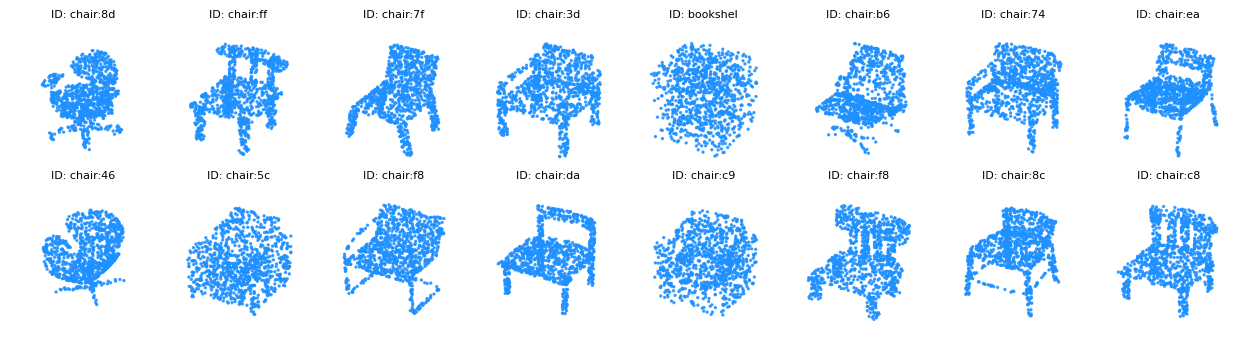

In [2]:
# Train on two classes from sampled_poincloud_5classes_1024:
class_ids = ["03001627", "02871439"]  # chair, bookshelf
class_names = {
    "03001627": "chair",
    "02871439": "bookshelf",
}

data_root = "./sampled_poincloud_5classes_1024/"

# Ensure category labels exist even if base mapping is incomplete.
for cid, cname in class_names.items():
    shapenet_id_to_category.setdefault(cid, cname)

datasets = [ShapeNetDataset(data_dir=data_root, object_class=cid) for cid in class_ids]
dataset = ConcatDataset(datasets)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

print(f"Using data root: {data_root}")
print(f"Using classes: {[class_names[cid] for cid in class_ids]} ({class_ids})")
print(f"Total shapes: {len(dataset)}")
print(f"Points per shape: {dataset[0]['points'].shape[0]}")

# Plot first batch
for batch in dataloader:
    pcs = batch['points']  # shape (B, N, 3)
    ids = batch['object_id']
    categories = batch['category']
    labels = [f"{c}:{i}" for c, i in zip(categories, ids)]
    pc_list = list(zip(labels, pcs))
    plot_pointclouds(pc_list, n_cols=8)
    break

In [3]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset
from model.base_model import PointCloudAE
from pytorch3d.loss import chamfer_distance
import numpy as np

from experiment_runner import ExperimentConfig, run_training

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# Shared configs for all runs
z_dim = 1024
num_epochs = 100
lr = 1e-3
val_split = 0.1
seed = 42

# 1024-point setup can usually handle larger batches than 5k/10k variants.
batch_size = 16

# Notebook-safe default: multiprocessing DataLoader workers can trigger
# "can only test a child process" cleanup errors in Jupyter.
num_workers = 0

torch.manual_seed(seed)
np.random.seed(seed)

num_points = dataset[0]["points"].shape[0]
all_indices = np.arange(len(dataset))
train_idx, val_idx = train_test_split(
    all_indices, test_size=val_split, random_state=seed, shuffle=True
)
train_set = Subset(dataset, train_idx)
val_set = Subset(dataset, val_idx)

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=num_workers,
    pin_memory=(device == "cuda"),
)
val_loader = DataLoader(
    val_set,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=(device == "cuda"),
)

print(f"Batch size: {batch_size}")
print(f"Training points per shape: {num_points}")
print(f"Training classes: {[class_names[cid] for cid in class_ids]}")

/ist-nas/users/pratchp/conda_envs/pyt3d/lib/python3.10/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


device: cuda
Batch size: 16
Training points per shape: 1024
Training classes: ['chair', 'bookshelf']


Selecting diverse interpolation anchors:   0%|          | 0/723 [00:00<?, ?it/s]

Selecting diverse interpolation anchors:   0%|          | 0/723 [00:00<?, ?it/s]

Selecting diverse interpolation anchors:   0%|          | 0/723 [00:00<?, ?it/s]

Selected val_set local indices: [64, 74, 72, 424]
Selected dataset indices: [3298, 2954, 6955, 7148]
Selected object_ids: ['7a79745b6bba49114ee3d18ae9bb4bb', '702cebffa33a19f019f079d1b712f46f', '6ebfa572d4501a9b680acf911e95b6a6', 'da85e3cd457b2306a64bdf68b802832']


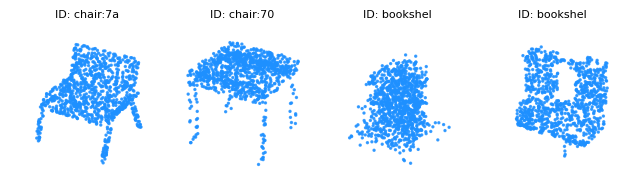

Created diverse_val_loader with 4 FPS-selected validation shapes.


In [4]:
# Select 4 maximally diverse validation shapes using shared helper
from utils.interpolation_anchors import build_diverse_anchor_loader

diverse_val_loader, diverse_local_idx, diverse_ids = build_diverse_anchor_loader(
    source_loader=val_loader,
    n_select=4,
    seed=seed,
    compute_device=device,
    show_progress=True,
)

# Map local val_set indices back to original dataset indices
diverse_dataset_idx = [int(val_idx[i]) for i in diverse_local_idx]

print("Selected val_set local indices:", diverse_local_idx)
print("Selected dataset indices:", diverse_dataset_idx)
print("Selected object_ids:", diverse_ids)

# Visual sanity check: these are the 4 anchors for hard interpolation.
anchor_batch = next(iter(diverse_val_loader))
anchor_labels = [
    f"{c}:{i}" for c, i in zip(anchor_batch["category"], anchor_batch["object_id"])
]
diverse_pc_list = list(zip(anchor_labels, anchor_batch["points"]))
plot_pointclouds(diverse_pc_list, n_cols=4)

print("Created diverse_val_loader with 4 FPS-selected validation shapes.")

## Baseline 1

In [5]:
import wandb
# wandb.login(key="")

In [6]:
# 1) Baseline experiment: Chamfer Distance only
model_cd = PointCloudAE(z_dim=z_dim, num_points=num_points)
optimizer_cd = torch.optim.Adam(model_cd.parameters(), lr=lr)
loss_fn_cd = lambda recon, points: chamfer_distance(
    recon.float(),
    points.float(),
    batch_reduction="mean",
    point_reduction="mean",
)[0]

class_tag = "chair_bookshelf"
cfg_cd = ExperimentConfig(
    name=f"baseline_cd_{class_tag}_{num_points}pts",
    num_epochs=num_epochs,
    seed=seed,
    use_amp=True,
    save_every=10,
    run_root="/ist-nas/ist-share/vision/pratchp/shapevae_weights/",
    epoch_log_every=10,
)

run_dir_cd, summary_cd = run_training(
    config=cfg_cd,
    model=model_cd,
    optimizer=optimizer_cd,
    loss_fn=loss_fn_cd,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
)
print("Baseline CD run dir:", run_dir_cd)
print("Baseline CD summary:", summary_cd)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/pratch/.netrc.
wandb: Currently logged in as: alephnir (alephnir-vistec) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


[baseline_cd_chair_bookshelf_1024pts] interpolation anchors selected: idx=[64, 74, 72, 424], ids=['7a79745b6bba49114ee3d18ae9bb4bb', '702cebffa33a19f019f079d1b712f46f', '6ebfa572d4501a9b680acf911e95b6a6', 'da85e3cd457b2306a64bdf68b802832']


train:baseline_cd_chair_bookshelf_1024pts:   0%|          | 0/45300 [00:00<?, ?it/s]

[baseline_cd_chair_bookshelf_1024pts] epoch 10/100 train 0.005079 val 0.005085 best 0.005085
[baseline_cd_chair_bookshelf_1024pts] epoch 20/100 train 0.004254 val 0.004616 best 0.004486
[baseline_cd_chair_bookshelf_1024pts] epoch 30/100 train 0.003801 val 0.004274 best 0.004274
[baseline_cd_chair_bookshelf_1024pts] epoch 40/100 train 0.003527 val 0.004174 best 0.004126
[baseline_cd_chair_bookshelf_1024pts] epoch 50/100 train 0.003343 val 0.004098 best 0.004092
[baseline_cd_chair_bookshelf_1024pts] epoch 60/100 train 0.003230 val 0.004123 best 0.004062
[baseline_cd_chair_bookshelf_1024pts] epoch 70/100 train 0.003127 val 0.004078 best 0.004044
[baseline_cd_chair_bookshelf_1024pts] epoch 80/100 train 0.003072 val 0.004075 best 0.004044
[baseline_cd_chair_bookshelf_1024pts] epoch 90/100 train 0.003023 val 0.004065 best 0.004004
[baseline_cd_chair_bookshelf_1024pts] epoch 100/100 train 0.002966 val 0.004079 best 0.004004


epoch,▁▁▁▁▁▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇██
train/loss,█▅▄▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/best,█▇▄▄▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/loss,█▇▅▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_epoch,86
best_val,0.004
epoch,100
run_dir,/ist-nas/ist-share/v...
train/loss,0.00297
val/best,0.004
val/loss,0.00408


Baseline CD run dir: /ist-nas/ist-share/vision/pratchp/shapevae_weights/20260427-014901_pratch_baseline_cd_chair_bookshelf_1024pts
Baseline CD summary: {'best_val': 0.004003882473942054, 'best_epoch': 86}


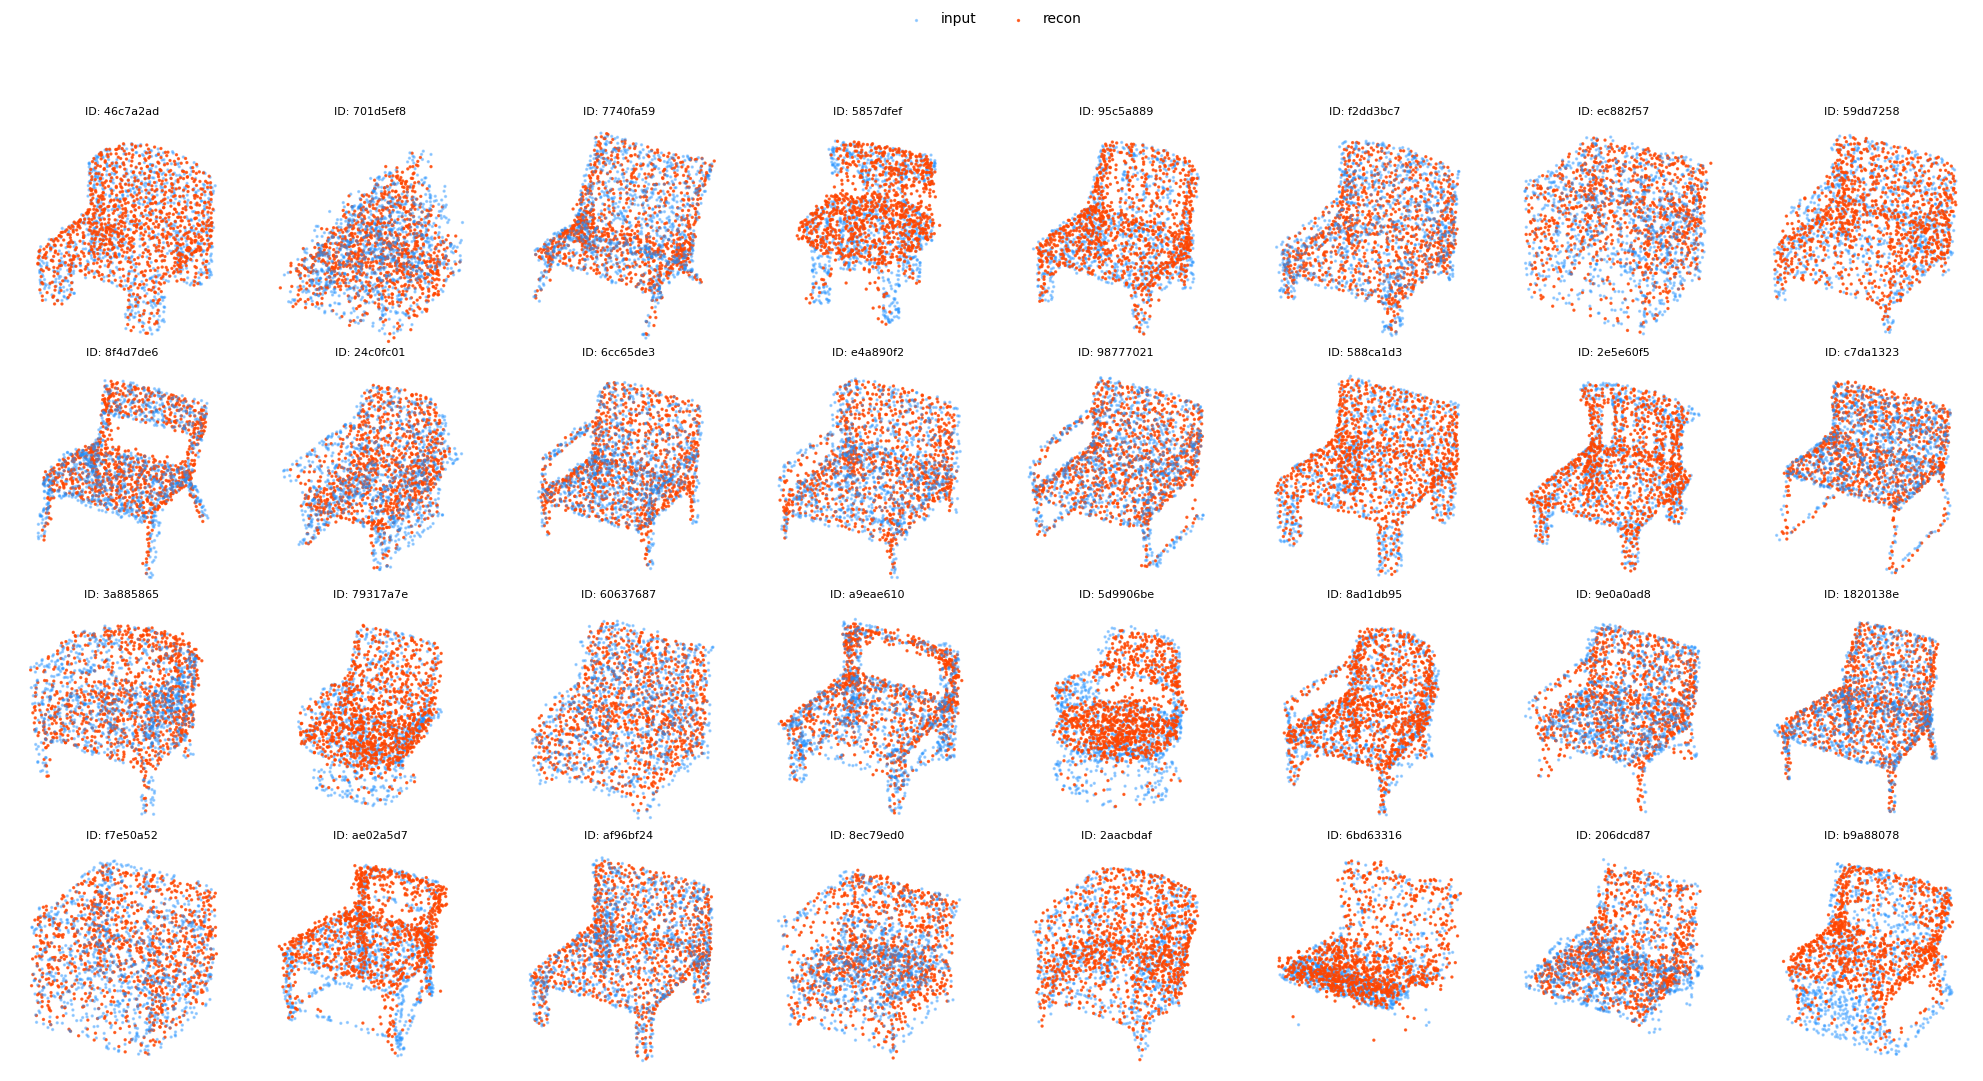

In [7]:
# Visualize baseline reconstructions across N validation batches
visualize_reconstructions(
    model=model_cd,
    loader=val_loader,
    device=device,
    num_batches=2,
    n_cols=8,
)